In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import os
from astropy.table import Table
import seaborn as sns
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

In [2]:

hdulist = fits.open("../anac_data/CIGALE-Final/out/observations.fits")
data = hdulist[1].data  # La tabla
print(data.columns)

ColDefs(
    name = 'redshift'; format = 'D'
    name = 'id'; format = '8A'
    name = 'F0378'; format = 'D'
    name = 'F0378_err'; format = 'D'
    name = 'F0395'; format = 'D'
    name = 'F0395_err'; format = 'D'
    name = 'F0410'; format = 'D'
    name = 'F0410_err'; format = 'D'
    name = 'F0430'; format = 'D'
    name = 'F0430_err'; format = 'D'
    name = 'F0515'; format = 'D'
    name = 'F0515_err'; format = 'D'
    name = 'F0660'; format = 'D'
    name = 'F0660_err'; format = 'D'
    name = 'F0861'; format = 'D'
    name = 'F0861_err'; format = 'D'
    name = 'sdss.up'; format = 'D'
    name = 'sdss.up_err'; format = 'D'
    name = 'sdss.gp'; format = 'D'
    name = 'sdss.gp_err'; format = 'D'
    name = 'sdss.rp'; format = 'D'
    name = 'sdss.rp_err'; format = 'D'
    name = 'sdss.ip'; format = 'D'
    name = 'sdss.ip_err'; format = 'D'
    name = 'sdss.zp'; format = 'D'
    name = 'sdss.zp_err'; format = 'D'
)


In [3]:
def convert_metallicity_to_FeH(Z, Z_solar=0.0152):
    """Convertir metalicidad Z a [Fe/H]"""
    return np.log10(Z / Z_solar)


In [4]:
def plot_splus_gc_sed_with_residuals(obj_id, 
                                    observations_file='../anac_data/CIGALE-Final/out/observations.fits', 
                                    results_file='../anac_data/CIGALE-Final/out/results.fits',
                                    output_dir='../anac_data/CIGALE-Final/',
                                    Z_solar=0.0152):
    """
    Gráfico SED especializado para cúmulos globulares con filtros S-PLUS + DECam/SDSS
    
    Parameters:
    -----------
    obj_id : str or int
        ID del objeto (cúmulo globular)
    observations_file : str
        Ruta al archivo observations.fits de CIGALE
    results_file : str
        Ruta al archivo results.fits de CIGALE  
    output_dir : str
        Directorio donde guardar el gráfico
    Z_solar : float
        Metalicidad solar (por defecto 0.0152 de Asplund+ 2009)
    """
    
    def get_actual_model_metallicity(obj_id, results_file):
        """Obtener la metalicidad REAL del modelo específico"""
        try:
            results = Table.read(results_file)
            res_obj = results[results['id'] == obj_id]
            
            # Buscar la metalicidad real del modelo (no el prior)
            # En CIGALE, la metalicidad del modelo real puede estar en diferentes columnas
            metallicity_keys = [
                'best.stellar.metallicity',
                'bayes.stellar.metallicity', 
                'stellar.metallicity'
            ]
            
            for key in metallicity_keys:
                if key in res_obj.colnames:
                    actual_Z = res_obj[key][0]
                    print(f"🔍 Metalicidad encontrada en '{key}': {actual_Z:.6f}")
                    return actual_Z
            
            # Si no encontramos ninguna columna específica, usar la por defecto
            default_Z = res_obj['best.stellar.metallicity'][0]
            print(f"⚠️  Usando metalicidad por defecto: {default_Z:.6f}")
            return default_Z
            
        except Exception as e:
            print(f"❌ Error obteniendo metalicidad real: {e}")
            return None
    
    try:
        # Leer archivos de CIGALE
        model = Table.read(f'../anac_data/CIGALE-Final/out/{obj_id}_best_model.fits')
        obs = Table.read(observations_file)
        results = Table.read(results_file)
        
        # Filtrar datos para el objeto específico
        obs_obj = obs[obs['id'] == obj_id]
        res_obj = results[results['id'] == obj_id]
        
        # Obtener parámetros físicos clave
        reduced_chi2 = res_obj['best.reduced_chi_square'][0]
        stellar_mass = res_obj['best.stellar.m_star'][0]
        
        # OBTENER METALICIDAD REAL DEL MODELO
        metallicity_Z = get_actual_model_metallicity(obj_id, results_file)
        if metallicity_Z is None:
            print("❌ No se pudo obtener la metalicidad real, usando valor por defecto")
            metallicity_Z = res_obj['bayes.stellar.metallicity'][0]
        
        age = res_obj['best.stellar.age_m_star'][0]
        
        # Convertir a [Fe/H]
        FeH = convert_metallicity_to_FeH(metallicity_Z, Z_solar)
        
        print(f"📊 Analizando objeto {obj_id}:")
        print(f"   Masa estelar: {stellar_mass:.2e} M_sun")
        print(f"   Metalicidad Z REAL: {metallicity_Z:.6f}")
        print(f"   [Fe/H]: {FeH:.3f}")
        print(f"   Edad: {age:.0f} Myr")
        print(f"   χ² reducido: {reduced_chi2:.2f}")
        
        # DEBUG: Mostrar comparación de valores
        print(f"🔍 Comparación:")
        print(f"   - Metalicidad real del modelo: {metallicity_Z:.6f}")
        
    except FileNotFoundError as e:
        print(f"❌ Error: No se encontró el objeto {obj_id}")
        print(f"   Asegúrate de que existe: ../anac_data/CIGALE-Final/out/{obj_id}_best_model.fits")
        return
    except Exception as e:
        print(f"❌ Error leyendo archivos: {e}")
        return

    # Configurar el gráfico con estilo para publicación
    plt.style.use('default')  # Reset para tener control total
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), 
                                  gridspec_kw={'height_ratios': [2, 1]})
    
    # Convertir nm a μm para mejor visualización
    wavelength_um = model['wavelength'] / 1000.0
    
    # --- Panel 1: SED completo ---
    # Modelo total - línea más fina y elegante
    ax1.loglog(wavelength_um, model['Fnu'], 'k-', linewidth=1.0, 
              label='Total Model', alpha=0.6)
    
    # Componentes (ajustados para cúmulos globulares)
    if 'stellar' in model.colnames:
        ax1.loglog(wavelength_um, model['stellar'], 'steelblue', alpha=0.6, 
                  linewidth=1.0, label='Stellar Component', linestyle='--')
    
    # Filtros S-PLUS (estrechos) - CUADRADOS VACÍOS
    splus_filters = {
        'F0378': (0.378, '#4A148C', 'J0378'),  # Púrpura oscuro
        'F0395': (0.395, '#6A1B9A', 'J0395'),  # Púrpura  
        'F0410': (0.410, '#283593', 'J0410'),  # Azul índigo
        'F0430': (0.430, '#0277BD', 'J0430'),  # Azul
        'F0515': (0.515, '#00897B', 'J0515'),  # Verde azulado
        'F0660': (0.660, '#E65100', 'J0660'),  # Naranja oscuro
        'F0861': (0.861, '#BF360C', 'J0861')   # Rojo oscuro
    }
    
    # Filtros DECam/SDSS (anchos) - TRIÁNGULOS VACÍOS
    decam_filters = {
        'sdss.up': (0.354, '#7B1FA2', 'u'),   # Púrpura
        'sdss.gp': (0.477, '#1976D2', 'g'),   # Azul
        'sdss.rp': (0.623, '#D32F2F', 'r'),   # Rojo
        'sdss.ip': (0.762, '#F57C00', 'i'),   # Naranja
        'sdss.zp': (0.913, '#388E3C', 'z')    # Verde
    }
    
    residuals_data = []
    
    # Plotear filtros S-PLUS (CUADRADOS)
    for filter_name, (wave, color, band_short) in splus_filters.items():
        if filter_name in obs_obj.colnames:
            # Flujo observado
            flux_obs = obs_obj[filter_name][0]
            flux_err = obs_obj[filter_name + '_err'][0]
            
            # Flujo del modelo (en results)
            model_flux_col = f'best.{filter_name}'
            if model_flux_col in res_obj.colnames:
                flux_model = res_obj[model_flux_col][0]
                
                # Calcular residuo normalizado
                residual = (flux_obs - flux_model) / flux_err
                
                # Plot observación - CUADRADOS VACÍOS para S-PLUS
                ax1.errorbar(wave, flux_obs, yerr=flux_err, 
                            fmt='s', markerfacecolor='none', markeredgecolor=color, 
                            markersize=10, capsize=3, markeredgewidth=1.5,
                            ecolor=color,  # Barras de error del mismo color
                            label=f'S-PLUS {band_short}', alpha=0.9, zorder=5)
                
                # Guardar datos para residuos
                residuals_data.append({
                    'band': f'S-PLUS {band_short}',
                    'filter_name': filter_name,
                    'wave': wave,
                    'obs': flux_obs,
                    'model': flux_model, 
                    'error': flux_err,
                    'residual': residual,
                    'color': color,
                    'marker': 's'  # Cuadrado para S-PLUS
                })
    
    # Plotear filtros DECam/SDSS (TRIÁNGULOS)
    for filter_name, (wave, color, band_short) in decam_filters.items():
        if filter_name in obs_obj.colnames:
            # Flujo observado
            flux_obs = obs_obj[filter_name][0]
            flux_err = obs_obj[filter_name + '_err'][0]
            
            # Flujo del modelo (en results)
            model_flux_col = f'best.{filter_name}'
            if model_flux_col in res_obj.colnames:
                flux_model = res_obj[model_flux_col][0]
                
                # Calcular residuo normalizado
                residual = (flux_obs - flux_model) / flux_err
                
                # Plot observación - TRIÁNGULOS VACÍOS para DECam/SDSS
                ax1.errorbar(wave, flux_obs, yerr=flux_err, 
                            fmt='^', markerfacecolor='none', markeredgecolor=color, 
                            markersize=10, capsize=3, markeredgewidth=1.5,
                            ecolor=color,  # Barras de error del mismo color
                            label=f'DECam {band_short}', alpha=0.9, zorder=5)
                
                # Guardar datos para residuos
                residuals_data.append({
                    'band': f'DECam {band_short}',
                    'filter_name': filter_name,
                    'wave': wave,
                    'obs': flux_obs,
                    'model': flux_model, 
                    'error': flux_err,
                    'residual': residual,
                    'color': color,
                    'marker': '^'  # Triángulo para DECam
                })
    
    # Plot flujo del modelo - CÍRCULOS SÓLIDOS DE COLOR ATRACTIVO (todos los filtros)
    # Solo mostramos uno en la leyenda
    model_plotted = False
    for data in residuals_data:
        if not model_plotted:
            ax1.plot(data['wave'], data['model'], marker='o', markersize=6,
                    markerfacecolor='#E91E63', markeredgecolor='#E91E63',
                    linestyle='', label=f'Model fluxes', alpha=0.9, zorder=4)
            model_plotted = True
        else:
            ax1.plot(data['wave'], data['model'], marker='o', markersize=6,
                    markerfacecolor='#E91E63', markeredgecolor='#E91E63',
                    linestyle='', alpha=0.9, zorder=4)
    
    # Configurar panel 1 - Estilo para publicación
    ax1.set_xlabel('Wavelength (μm)', fontsize=18, fontweight='normal')
    ax1.set_ylabel('Flux (mJy)', fontsize=18, fontweight='normal')
    
    # Título con [Fe/H] REAL del modelo
    title_text = (f'GC {obj_id} | '
                 f'M = {stellar_mass:.2e} M$_\odot$ | '
                 f'[Fe/H] = {FeH:.2f} | '
                 f'Age = {age/1000:.1f} Gyr | '
                 f'$\chi^2$ = {reduced_chi2:.2f}')
    ax1.set_title(title_text, fontsize=16, pad=10)
    
    # --- SOLUCIÓN AL PROBLEMA DE FORMATO EN EJE Y ---
    # Configurar formato de ticks en notación científica limpia
    from matplotlib.ticker import ScalarFormatter
    
    # Para el eje Y (logarítmico) - usar formato más limpio
    class CleanScientificFormatter(ScalarFormatter):
        def __init__(self):
            ScalarFormatter.__init__(self)
            self.set_scientific(True)
            self.set_powerlimits((-2, 2))
        
        def format_data(self, value):
            # Redondear a 2 decimales en notación científica
            if value == 0:
                return "0"
            exponent = np.floor(np.log10(abs(value)))
            coeff = value / 10**exponent
            # Redondear coeficiente a 1 decimal
            coeff_rounded = round(coeff, 1)
            # Si redondea a 10, ajustar
            if coeff_rounded == 10.0:
                coeff_rounded = 1.0
                exponent += 1
            return f"${coeff_rounded:.1f} \\times 10^{{{int(exponent)}}}$"
    
    # Aplicar formateador personalizado
    ax1.yaxis.set_major_formatter(CleanScientificFormatter())
    
    # Asegurar que los ticks sean números redondos
    import matplotlib.ticker as ticker
    ax1.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0, 2.0, 5.0), numticks=12))
    
    # Leyenda mejorada y compacta
    handles, labels = ax1.get_legend_handles_labels()
    # Mantener solo una entrada por tipo (no duplicados por filtro)
    unique_labels = []
    unique_handles = []
    for handle, label in zip(handles, labels):
        if label not in unique_labels:
            unique_labels.append(label)
            unique_handles.append(handle)
    
    # Ordenar leyenda: primero componentes del modelo, luego observaciones
    model_handles = [h for h, l in zip(unique_handles, unique_labels) if 'Model' in l or 'Component' in l]
    model_labels = [l for l in unique_labels if 'Model' in l or 'Component' in l]
    
    # Separar S-PLUS y DECam en la leyenda
    splus_handles = [h for h, l in zip(unique_handles, unique_labels) if 'S-PLUS' in l]
    splus_labels = [l for l in unique_labels if 'S-PLUS' in l]
    
    decam_handles = [h for h, l in zip(unique_handles, unique_labels) if 'DECam' in l]
    decam_labels = [l for l in unique_labels if 'DECam' in l]
    
    # Reconstruir leyenda ordenada
    ordered_handles = model_handles + splus_handles + decam_handles
    ordered_labels = model_labels + splus_labels + decam_labels
    
    # Crear leyenda con columnas separadas
    n_columns = 3 if len(ordered_labels) > 10 else 2
    ax1.legend(ordered_handles, ordered_labels, loc='best', 
              ncol=n_columns, fontsize=10, framealpha=0.9, fancybox=True,
              columnspacing=0.8, handletextpad=0.5)
    
    ax1.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
    ax1.set_xlim(0.3, 1.0)
    ax1.xaxis.set_visible(False) 
    
    # Mejorar los ticks del eje Y
    ax1.tick_params(axis='y', which='major', labelsize=14)
    ax1.tick_params(axis='y', which='minor', labelsize=12)
    
    # Ajuste automático del rango Y
    if residuals_data:
        all_fluxes = [d['obs'] for d in residuals_data] + [d['model'] for d in residuals_data]
        min_flux = min(all_fluxes) * 0.3
        max_flux = max(all_fluxes) * 3.0
        
        # Asegurar límites en potencias de 10 redondas
        min_exp = np.floor(np.log10(min_flux))
        max_exp = np.ceil(np.log10(max_flux))
        ax1.set_ylim(10**min_exp, 10**max_exp)
    
    # --- Panel 2: Residuos ---
    if residuals_data:
        # Ordenar por longitud de onda para conectar puntos correctamente
        residuals_data.sort(key=lambda x: x['wave'])
        
        bands = [d['band'] for d in residuals_data]
        waves = [d['wave'] for d in residuals_data]
        residuals = [d['residual'] for d in residuals_data]
        colors = [d['color'] for d in residuals_data]
        markers = [d['marker'] for d in residuals_data]
        
        # Plot residuos - mantener colores y marcadores originales de filtros
        for i, (band, wave, residual, color, marker) in enumerate(zip(bands, waves, residuals, colors, markers)):
            ax2.scatter(wave, residual, color=color, s=80, zorder=3, 
                       marker=marker, label=f'{band}', alpha=0.8, edgecolors='black', linewidth=0.5)
            
            # Conectar puntos con líneas para mejor visualización
            if i > 0:
                prev_wave = waves[i-1]
                prev_residual = residuals[i-1]
                ax2.plot([prev_wave, wave], [prev_residual, residual], 
                        'gray', alpha=0.3, linestyle='-', linewidth=1)
        
        # Líneas de referencia más sutiles
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1)
        ax2.axhline(y=1, color='red', linestyle='--', alpha=0.4, linewidth=0.8)
        ax2.axhline(y=-1, color='red', linestyle='--', alpha=0.4, linewidth=0.8)
        ax2.axhline(y=2, color='red', linestyle=':', alpha=0.3, linewidth=0.6)
        ax2.axhline(y=-2, color='red', linestyle=':', alpha=0.3, linewidth=0.6)
        
        ax2.set_xlabel('Wavelength (μm)', fontsize=18, fontweight='normal')
        ax2.set_ylabel('Residual (σ)', fontsize=18, fontweight='normal')
        ax2.tick_params(axis='both', which='major', labelsize=14)
        
        # Leyenda para residuos (opcional, puede ser muy grande)
        # ax2.legend(loc='best', ncol=2, fontsize=8, framealpha=0.9)
        
        ax2.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
        ax2.set_xscale('log')
        ax2.set_xlim(0.3, 1.0) 
        
        # Ajustar límites Y para residuos
        max_res = max(3, max(np.abs(residuals)) * 1.2)
        ax2.set_ylim(-max_res, max_res)
        
        # Formatear eje X en residuos para que sea más legible
        ax2.xaxis.set_major_formatter(ScalarFormatter())
        ax2.xaxis.set_major_locator(ticker.FixedLocator([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]))
        ax2.set_xticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
        ax2.set_xticklabels(['0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0'])
    
    # Ajustes finales de estilo
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.05)  # Menos espacio entre subplots
    
    # Guardar gráfico con alta calidad para publicación
    output_path = f'{output_dir}/{obj_id}_SED_S-PLUS_DECam.png'
    output_path1 = f'{output_dir}/{obj_id}_SED_S-PLUS_DECam.pdf'
    
    plt.savefig(output_path, dpi=350, bbox_inches='tight', facecolor='white', 
                transparent=False, pad_inches=0.1)
    plt.savefig(output_path1, dpi=350, bbox_inches='tight', facecolor='white', 
                transparent=False, pad_inches=0.1)
    
    print(f"✅ Gráfico guardado: {output_path}")
    plt.show()
    
    # Imprimir tabla de residuos detallada
    if residuals_data:
        print(f"\n{'='*70}")
        print(f"ANÁLISIS DE RESIDUOS - Cúmulo Globular {obj_id}")
        print(f"{'='*70}")
        print(f"{'Filtro':<15} {'λ (μm)':<8} {'Obs (mJy)':<12} {'Model (mJy)':<12} {'Residuo (σ)':<12} {'|Residuo|':<10}")
        print(f"{'-'*70}")
        
        for data in residuals_data:
            abs_residual = abs(data['residual'])
            print(f"{data['band']:<15} {data['wave']:<8.3f} {data['obs']:<12.6f} "
                  f"{data['model']:<12.6f} {data['residual']:<12.2f} {abs_residual:<10.2f}")
        
        print(f"{'-'*70}")
        avg_abs_residual = np.mean([abs(d['residual']) for d in residuals_data])
        print(f"Residuo absoluto promedio: {avg_abs_residual:.2f}σ")
        print(f"Número de puntos: {len(residuals_data)}")
        
        # Separar por tipo de filtro
        splus_residuals = [abs(d['residual']) for d in residuals_data if 'S-PLUS' in d['band']]
        decam_residuals = [abs(d['residual']) for d in residuals_data if 'DECam' in d['band']]
        
        if splus_residuals:
            print(f"S-PLUS (estrechos): {np.mean(splus_residuals):.2f}σ promedio")
        if decam_residuals:
            print(f"DECam/SDSS (anchos): {np.mean(decam_residuals):.2f}σ promedio")
        
        print(f"{'='*70}")

# Función auxiliar para plotear múltiples objetos
def plot_multiple_gcs(obj_ids, **kwargs):
    """
    Plotear SEDs para múltiples cúmulos globulares
    
    Parameters:
    -----------
    obj_ids : list
        Lista de IDs de objetos a plotear
    **kwargs : 
        Argumentos adicionales para plot_splus_gc_sed_with_residuals
    """
    for obj_id in obj_ids:
        print(f"\n{'#'*60}")
        print(f"PROCESANDO OBJETO: {obj_id}")
        print(f"{'#'*60}")
        plot_splus_gc_sed_with_residuals(obj_id, **kwargs)

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.030000
📊 Analizando objeto T17-2602:
   Masa estelar: 2.67e+06 M_sun
   Metalicidad Z REAL: 0.030000
   [Fe/H]: 0.295
   Edad: 6281 Myr
   χ² reducido: 1.60
🔍 Comparación:
   - Metalicidad real del modelo: 0.030000
✅ Gráfico guardado: ../anac_data/CIGALE-Final//T17-2602_SED_S-PLUS_DECam.png


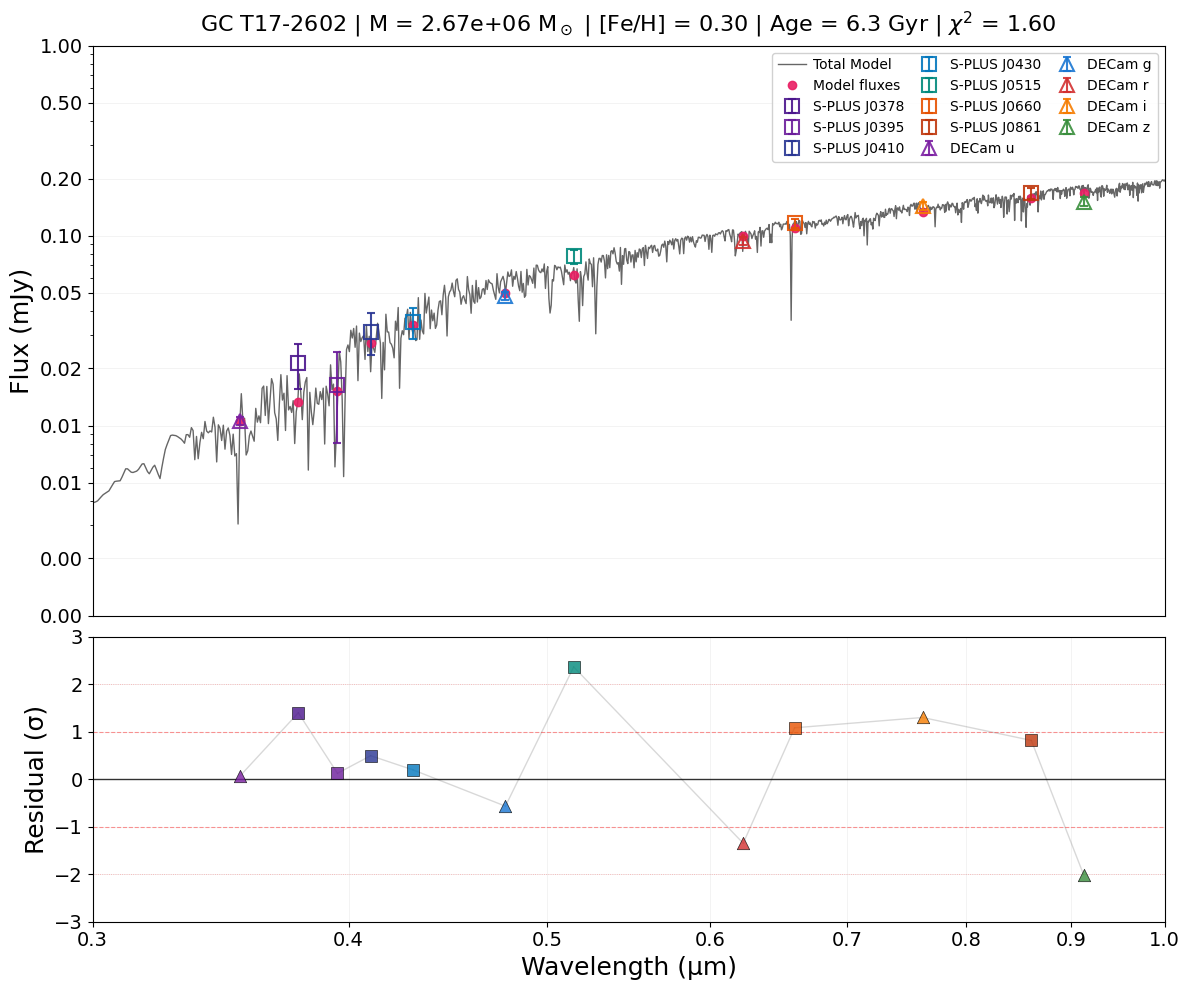


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2602
Filtro          λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
----------------------------------------------------------------------
DECam u         0.354    0.010569     0.010532     0.07         0.07      
S-PLUS J0378    0.378    0.021280     0.013252     1.40         1.40      
S-PLUS J0395    0.395    0.016312     0.015278     0.13         0.13      
S-PLUS J0410    0.410    0.031217     0.027336     0.50         0.50      
S-PLUS J0430    0.430    0.035083     0.033797     0.20         0.20      
DECam g         0.477    0.048309     0.049700     -0.57        0.57      
S-PLUS J0515    0.515    0.077707     0.061728     2.37         2.37      
DECam r         0.623    0.093762     0.100183     -1.35        1.35      
S-PLUS J0660    0.660    0.116560     0.109422     1.08         1.08      
DECam i         0.762    0.143227     0.133748     1.30         1.30      
S-PLUS J0861    0.861    0.167033     0.157482     0.82

In [5]:
# Ejemplo de uso:
if __name__ == "__main__":
    # Plotear un objeto individual
    plot_splus_gc_sed_with_residuals('T17-2602')


## Other example

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.030000
📊 Analizando objeto T17-2211:
   Masa estelar: 1.10e+06 M_sun
   Metalicidad Z REAL: 0.030000
   [Fe/H]: 0.295
   Edad: 5643 Myr
   χ² reducido: 1.79
🔍 Comparación:
   - Metalicidad real del modelo: 0.030000
✅ Gráfico guardado: ../anac_data/CIGALE-Final//T17-2211_SED_S-PLUS_DECam.png


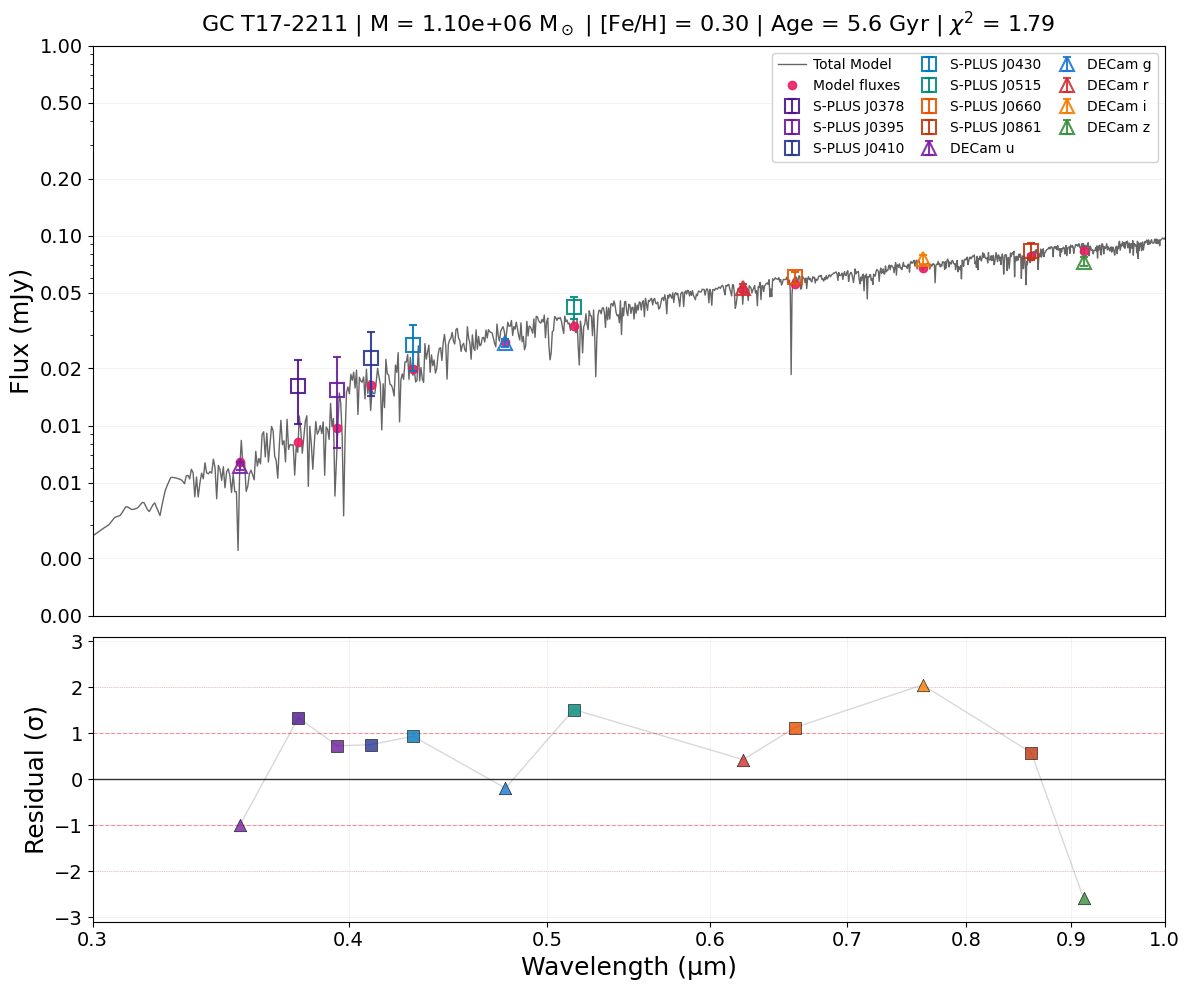


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2211
Filtro          λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
----------------------------------------------------------------------
DECam u         0.354    0.006138     0.006449     -1.00        1.00      
S-PLUS J0378    0.378    0.016154     0.008244     1.34         1.34      
S-PLUS J0395    0.395    0.015309     0.009713     0.73         0.73      
S-PLUS J0410    0.410    0.022751     0.016353     0.75         0.75      
S-PLUS J0430    0.430    0.026577     0.019744     0.94         0.94      
DECam g         0.477    0.027291     0.027560     -0.19        0.19      
S-PLUS J0515    0.515    0.042196     0.033651     1.52         1.52      
DECam r         0.623    0.052970     0.051817     0.43         0.43      
S-PLUS J0660    0.660    0.060499     0.055924     1.12         1.12      
DECam i         0.762    0.075167     0.067317     2.05         2.05      
S-PLUS J0861    0.861    0.083140     0.078206     0.58

In [6]:
plot_splus_gc_sed_with_residuals('T17-2211')

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.030000
📊 Analizando objeto T17-2684:
   Masa estelar: 2.46e+06 M_sun
   Metalicidad Z REAL: 0.030000
   [Fe/H]: 0.295
   Edad: 11998 Myr
   χ² reducido: 1.20
🔍 Comparación:
   - Metalicidad real del modelo: 0.030000
✅ Gráfico guardado: ../anac_data/CIGALE-Final//T17-2684_SED_S-PLUS_DECam.png


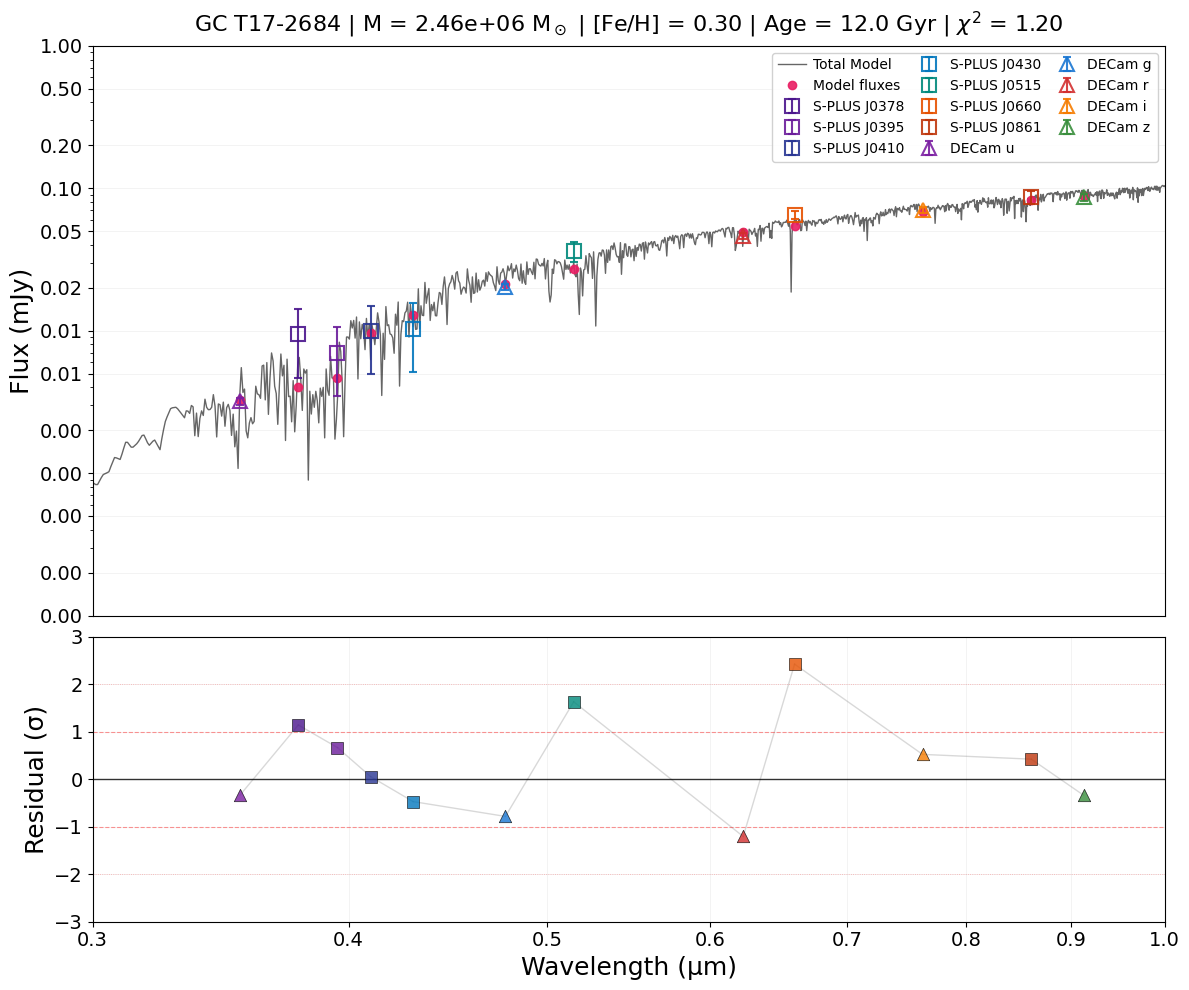


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2684
Filtro          λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
----------------------------------------------------------------------
DECam u         0.354    0.003192     0.003249     -0.34        0.34      
S-PLUS J0378    0.378    0.009411     0.004000     1.14         1.14      
S-PLUS J0395    0.395    0.007014     0.004660     0.67         0.67      
S-PLUS J0410    0.410    0.009968     0.009690     0.06         0.06      
S-PLUS J0430    0.430    0.010337     0.012776     -0.47        0.47      
DECam g         0.477    0.020325     0.021133     -0.78        0.78      
S-PLUS J0515    0.515    0.036126     0.026887     1.63         1.63      
DECam r         0.623    0.046135     0.048961     -1.20        1.20      
S-PLUS J0660    0.660    0.065133     0.054703     2.43         2.43      
DECam i         0.762    0.070474     0.068594     0.52         0.52      
S-PLUS J0861    0.861    0.086497     0.082622     0.42

In [7]:
plot_splus_gc_sed_with_residuals('T17-2684')

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.030000
📊 Analizando objeto T17-2698:
   Masa estelar: 1.75e+06 M_sun
   Metalicidad Z REAL: 0.030000
   [Fe/H]: 0.295
   Edad: 8997 Myr
   χ² reducido: 1.33
🔍 Comparación:
   - Metalicidad real del modelo: 0.030000
✅ Gráfico guardado: ../anac_data/CIGALE-Final//T17-2698_SED_S-PLUS_DECam.png


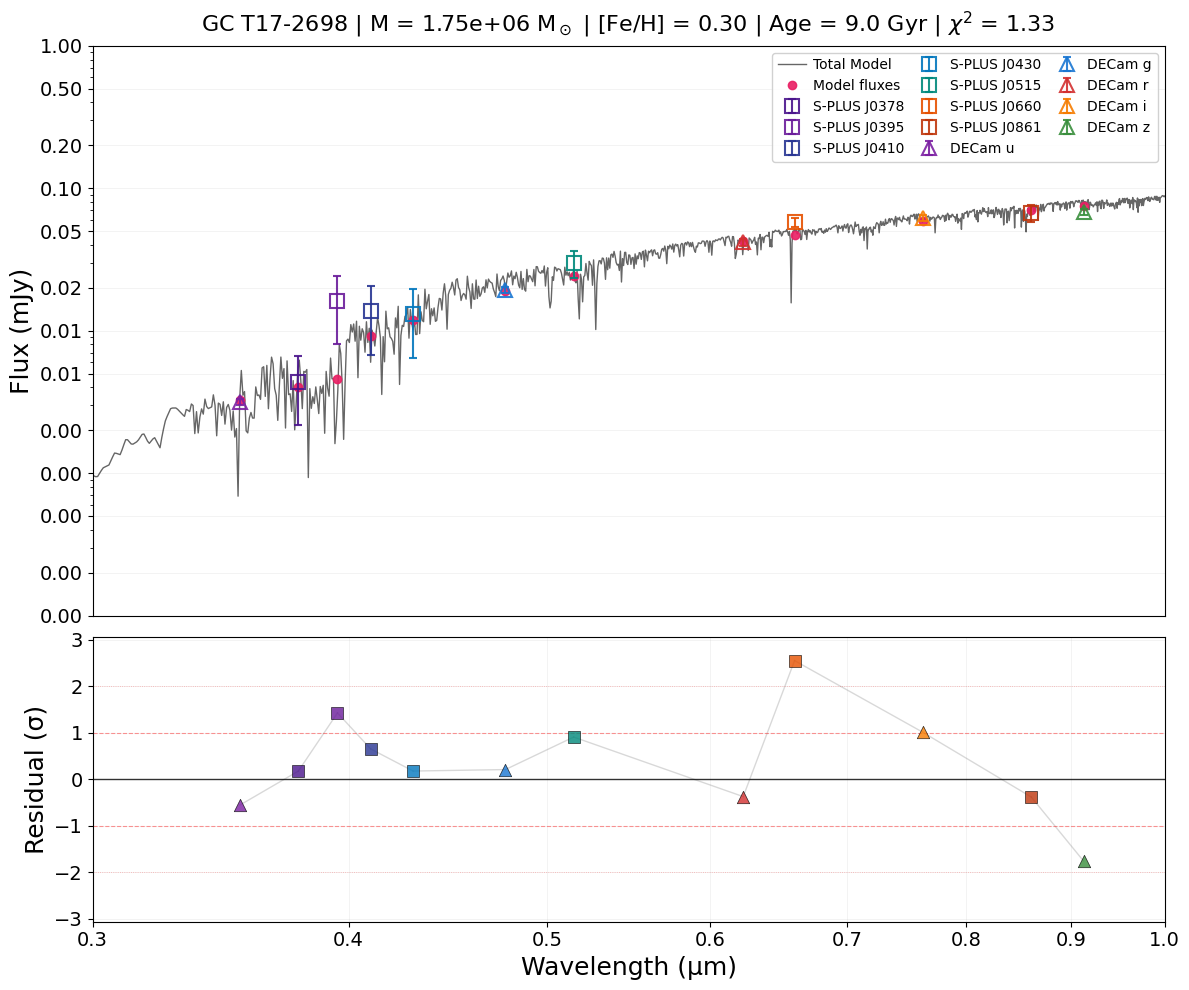


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2698
Filtro          λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
----------------------------------------------------------------------
DECam u         0.354    0.003162     0.003256     -0.56        0.56      
S-PLUS J0378    0.378    0.004389     0.004000     0.18         0.18      
S-PLUS J0395    0.395    0.016111     0.004554     1.43         1.43      
S-PLUS J0410    0.410    0.013662     0.009177     0.65         0.65      
S-PLUS J0430    0.430    0.013015     0.011856     0.18         0.18      
DECam g         0.477    0.019232     0.019027     0.21         0.21      
S-PLUS J0515    0.515    0.029780     0.024113     0.91         0.91      
DECam r         0.623    0.041689     0.042478     -0.37        0.37      
S-PLUS J0660    0.660    0.057732     0.047165     2.55         2.55      
DECam i         0.762    0.061948     0.058751     1.01         1.01      
S-PLUS J0861    0.861    0.066898     0.070344     -0.3

In [8]:
plot_splus_gc_sed_with_residuals('T17-2698')

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.030000
📊 Analizando objeto T17-2731:
   Masa estelar: 1.12e+06 M_sun
   Metalicidad Z REAL: 0.030000
   [Fe/H]: 0.295
   Edad: 1910 Myr
   χ² reducido: 1.64
🔍 Comparación:
   - Metalicidad real del modelo: 0.030000
✅ Gráfico guardado: ../anac_data/CIGALE-Final//T17-2731_SED_S-PLUS_DECam.png


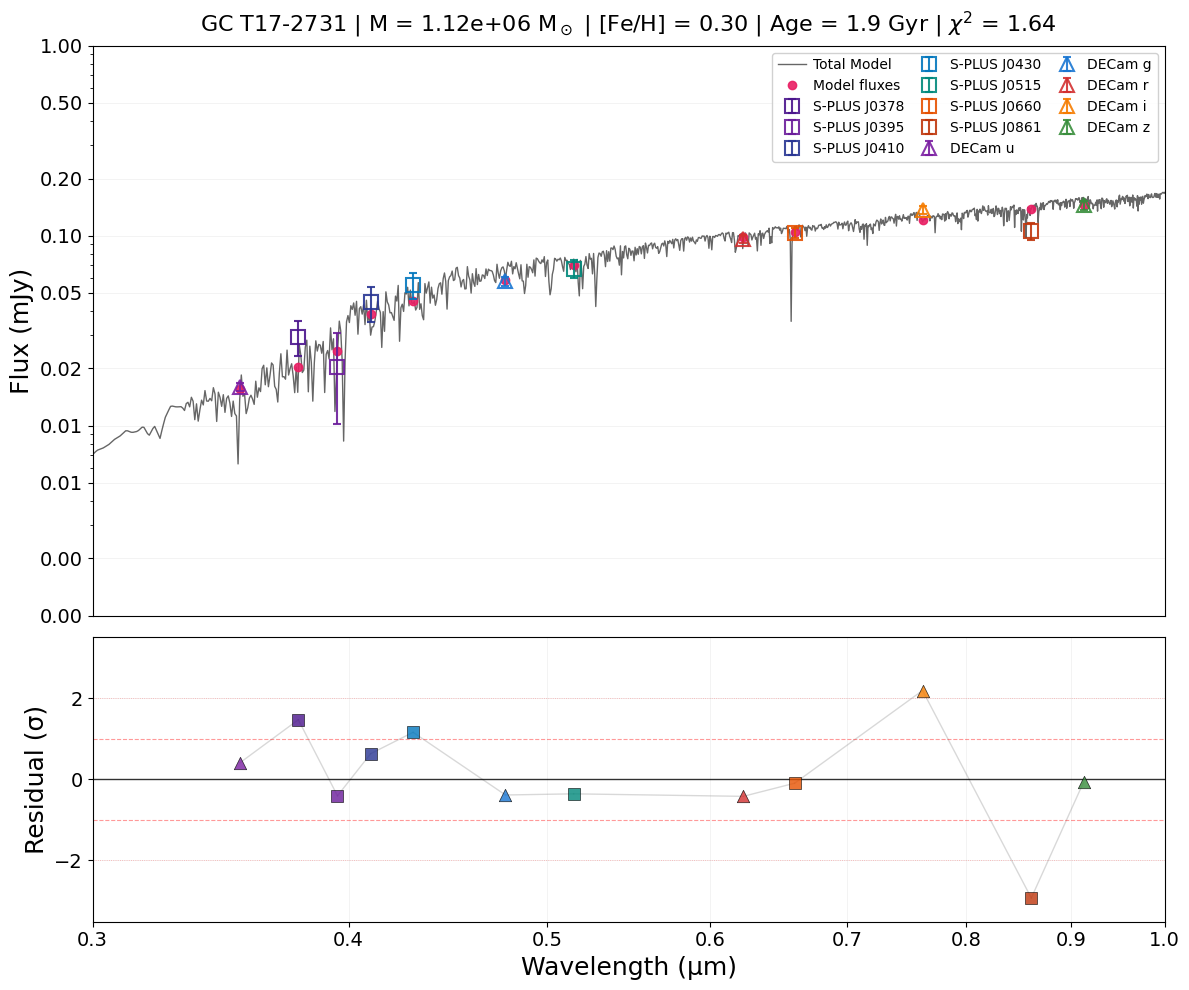


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2731
Filtro          λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
----------------------------------------------------------------------
DECam u         0.354    0.015997     0.015666     0.41         0.41      
S-PLUS J0378    0.378    0.029382     0.020386     1.47         1.47      
S-PLUS J0395    0.395    0.020425     0.024591     -0.41        0.41      
S-PLUS J0410    0.410    0.044501     0.038607     0.63         0.63      
S-PLUS J0430    0.430    0.054893     0.045207     1.16         1.16      
DECam g         0.477    0.057547     0.058680     -0.39        0.39      
S-PLUS J0515    0.515    0.067154     0.069814     -0.36        0.36      
DECam r         0.623    0.096389     0.098450     -0.42        0.42      
S-PLUS J0660    0.660    0.103329     0.103958     -0.10        0.10      
DECam i         0.762    0.136781     0.121557     2.19         2.19      
S-PLUS J0861    0.861    0.105874     0.137550     -2.9

In [9]:
plot_splus_gc_sed_with_residuals('T17-2731')

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.004000
📊 Analizando objeto T17-2741:
   Masa estelar: 1.46e+06 M_sun
   Metalicidad Z REAL: 0.004000
   [Fe/H]: -0.580
   Edad: 8997 Myr
   χ² reducido: 0.98
🔍 Comparación:
   - Metalicidad real del modelo: 0.004000
✅ Gráfico guardado: ../anac_data/CIGALE-Final//T17-2741_SED_S-PLUS_DECam.png


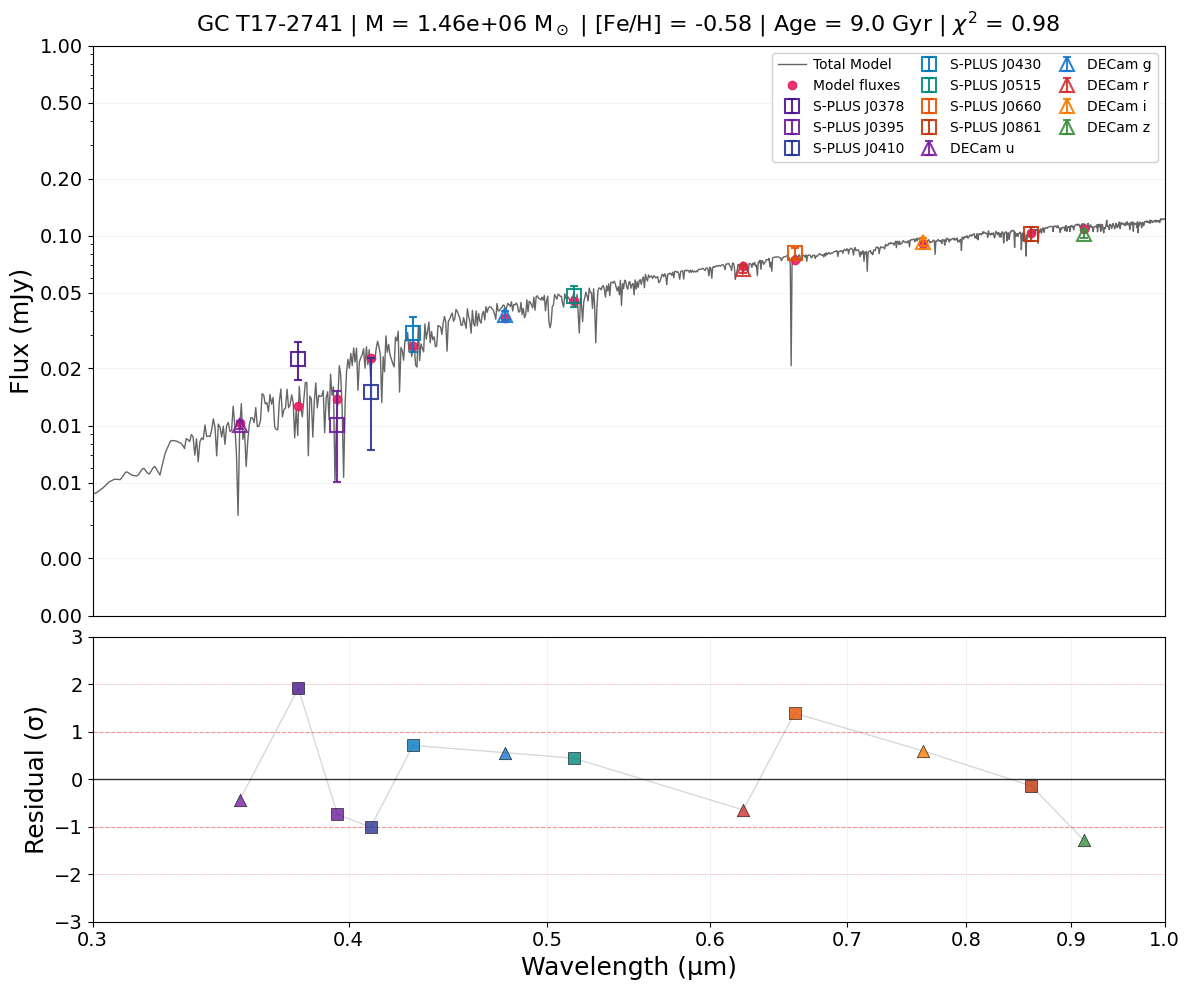


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2741
Filtro          λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
----------------------------------------------------------------------
DECam u         0.354    0.010093     0.010312     -0.43        0.43      
S-PLUS J0378    0.378    0.022526     0.012723     1.91         1.91      
S-PLUS J0395    0.395    0.010090     0.013839     -0.74        0.74      
S-PLUS J0410    0.410    0.015040     0.022647     -1.01        1.01      
S-PLUS J0430    0.430    0.030773     0.026236     0.71         0.71      
DECam g         0.477    0.038021     0.036938     0.56         0.56      
S-PLUS J0515    0.515    0.048311     0.045509     0.44         0.44      
DECam r         0.623    0.066685     0.068872     -0.65        0.65      
S-PLUS J0660    0.660    0.081197     0.074377     1.39         1.39      
DECam i         0.762    0.092902     0.090060     0.60         0.60      
S-PLUS J0861    0.861    0.102620     0.103837     -0.1

In [10]:
plot_splus_gc_sed_with_residuals('T17-2741')

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.030000
📊 Analizando objeto T17-3019:
   Masa estelar: 2.87e+06 M_sun
   Metalicidad Z REAL: 0.030000
   [Fe/H]: 0.295
   Edad: 3139 Myr
   χ² reducido: 0.73
🔍 Comparación:
   - Metalicidad real del modelo: 0.030000
✅ Gráfico guardado: ../anac_data/CIGALE-Final//T17-3019_SED_S-PLUS_DECam.png


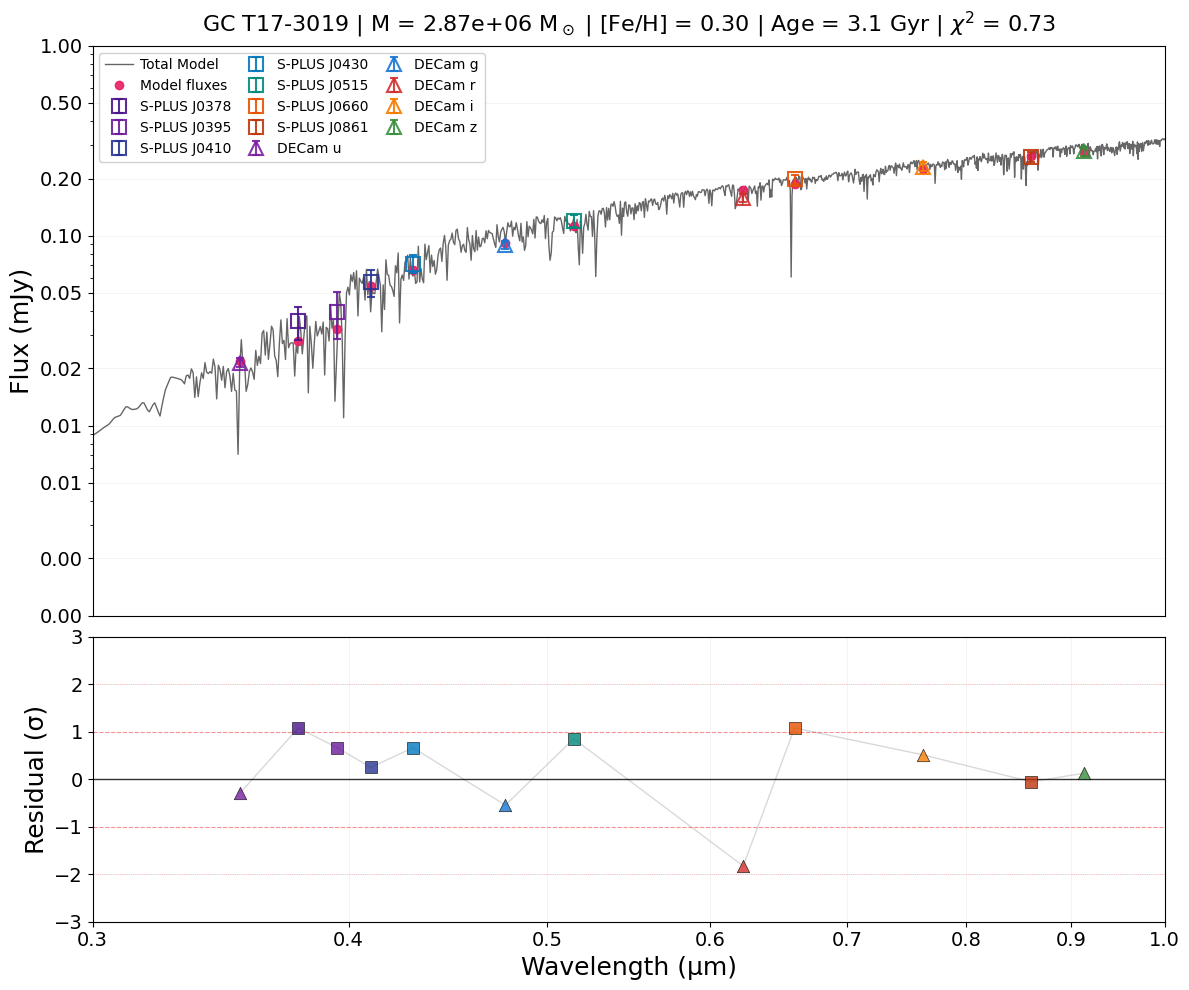


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-3019
Filtro          λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
----------------------------------------------------------------------
DECam u         0.354    0.021480     0.021799     -0.29        0.29      
S-PLUS J0378    0.378    0.035356     0.027830     1.08         1.08      
S-PLUS J0395    0.395    0.039525     0.032285     0.66         0.66      
S-PLUS J0410    0.410    0.056842     0.054501     0.25         0.25      
S-PLUS J0430    0.430    0.071012     0.065875     0.66         0.66      
DECam g         0.477    0.089542     0.092025     -0.55        0.55      
S-PLUS J0515    0.515    0.120185     0.112843     0.85         0.85      
DECam r         0.623    0.158499     0.173223     -1.83        1.83      
S-PLUS J0660    0.660    0.198543     0.186945     1.08         1.08      
DECam i         0.762    0.231220     0.225148     0.52         0.52      
S-PLUS J0861    0.861    0.260528     0.261391     -0.0

In [11]:
plot_splus_gc_sed_with_residuals('T17-3019')

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.030000
📊 Analizando objeto T17-2911:
   Masa estelar: 3.64e+06 M_sun
   Metalicidad Z REAL: 0.030000
   [Fe/H]: 0.295
   Edad: 10997 Myr
   χ² reducido: 2.59
🔍 Comparación:
   - Metalicidad real del modelo: 0.030000
✅ Gráfico guardado: ../anac_data/CIGALE-Final//T17-2911_SED_S-PLUS_DECam.png


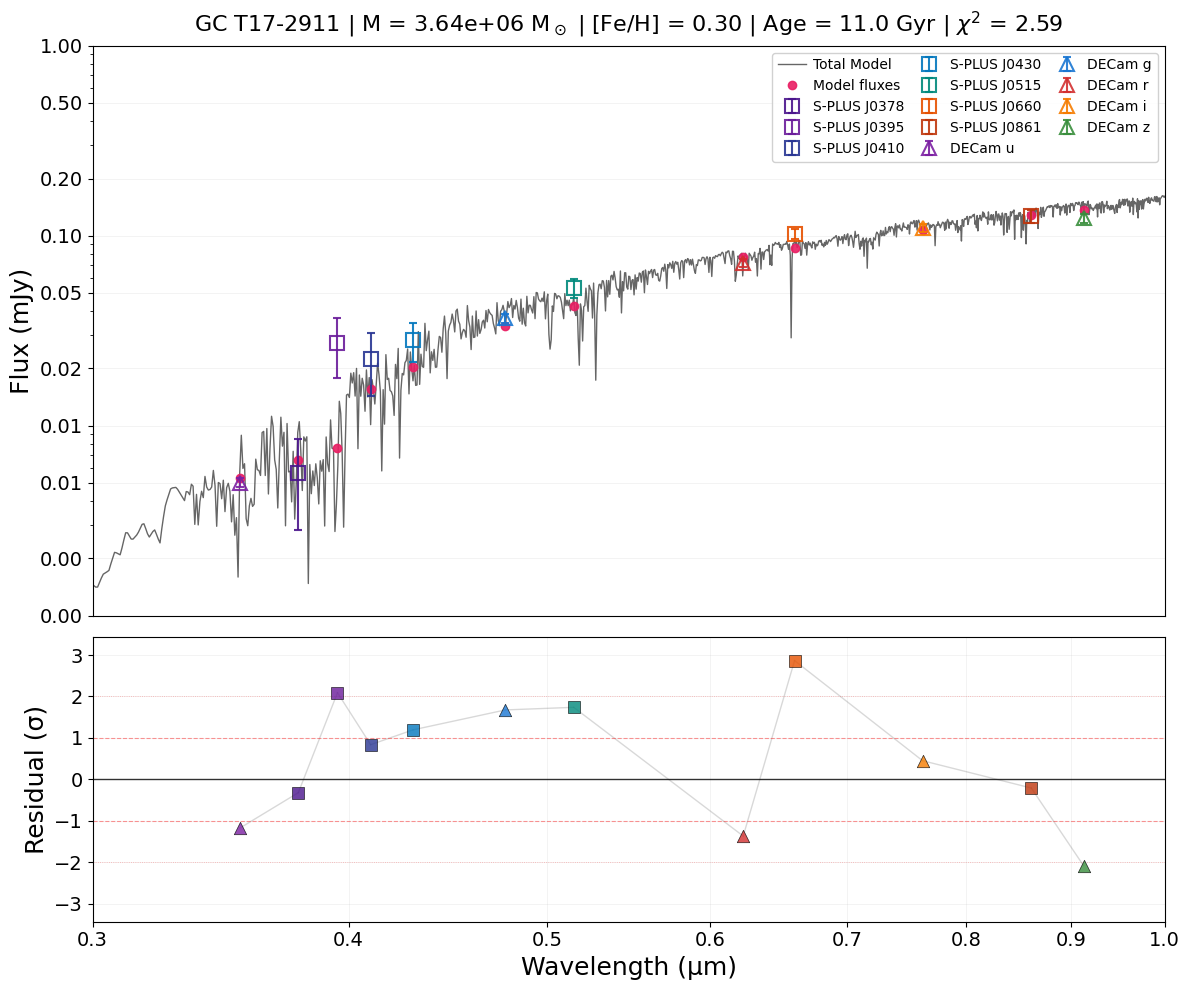


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2911
Filtro          λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
----------------------------------------------------------------------
DECam u         0.354    0.005012     0.005327     -1.18        1.18      
S-PLUS J0378    0.378    0.005642     0.006558     -0.32        0.32      
S-PLUS J0395    0.395    0.027248     0.007579     2.09         2.09      
S-PLUS J0410    0.410    0.022536     0.015619     0.84         0.84      
S-PLUS J0430    0.430    0.028144     0.020457     1.19         1.19      
DECam g         0.477    0.036646     0.033525     1.68         1.68      
S-PLUS J0515    0.515    0.052914     0.042602     1.74         1.74      
DECam r         0.623    0.071784     0.076787     -1.37        1.37      
S-PLUS J0660    0.660    0.102443     0.085631     2.87         2.87      
DECam i         0.762    0.109654     0.107149     0.45         0.45      
S-PLUS J0861    0.861    0.126642     0.128773     -0.2

In [12]:
plot_splus_gc_sed_with_residuals('T17-2911')

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.020000
📊 Analizando objeto T17-2818:
   Masa estelar: 7.66e+05 M_sun
   Metalicidad Z REAL: 0.020000
   [Fe/H]: 0.119
   Edad: 6269 Myr
   χ² reducido: 2.69
🔍 Comparación:
   - Metalicidad real del modelo: 0.020000
✅ Gráfico guardado: ../anac_data/CIGALE-Final//T17-2818_SED_S-PLUS_DECam.png


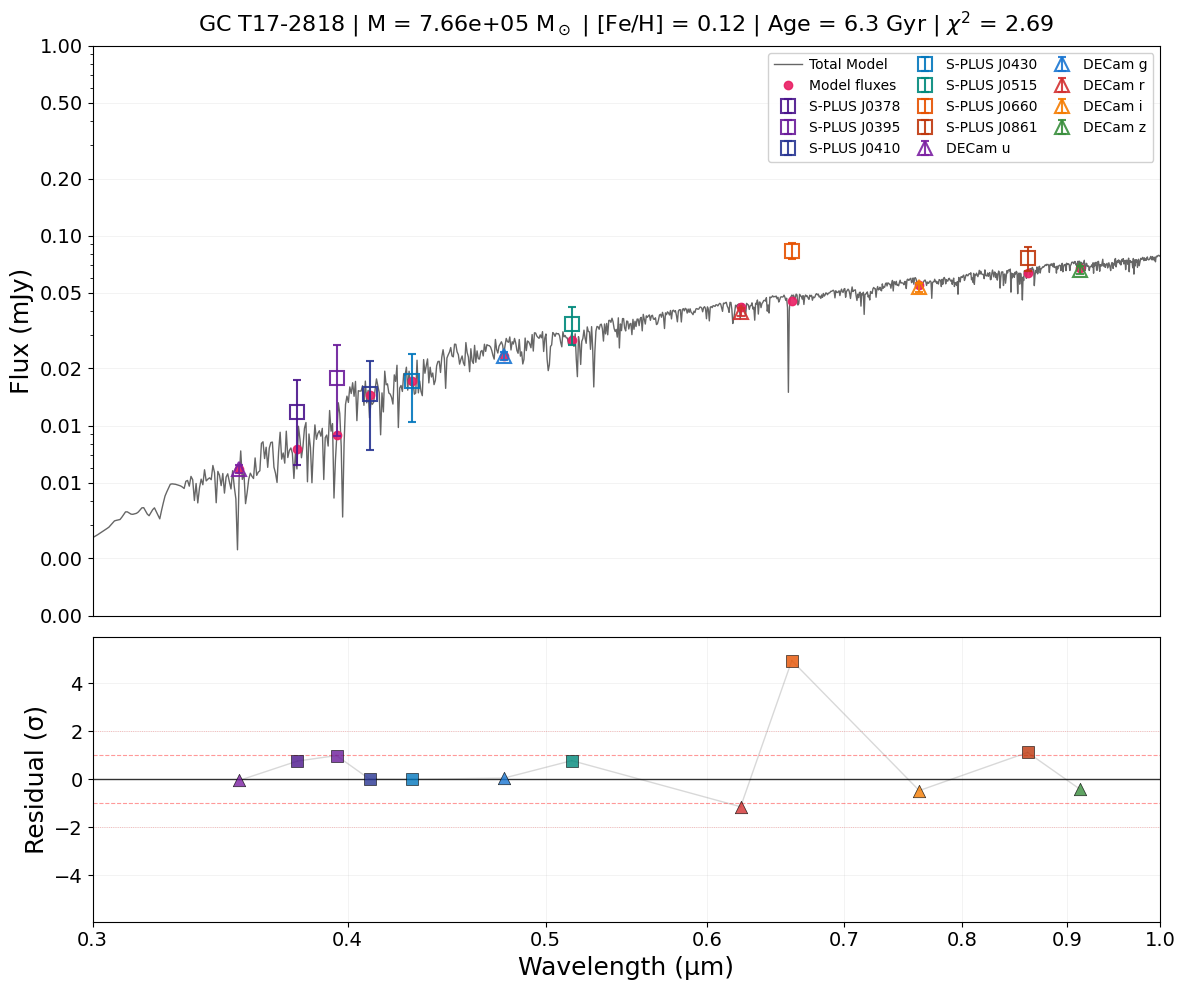


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2818
Filtro          λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
----------------------------------------------------------------------
DECam u         0.354    0.005916     0.005930     -0.05        0.05      
S-PLUS J0378    0.378    0.011802     0.007510     0.76         0.76      
S-PLUS J0395    0.395    0.017710     0.008907     0.99         0.99      
S-PLUS J0410    0.410    0.014597     0.014551     0.01         0.01      
S-PLUS J0430    0.430    0.017073     0.017081     -0.00        0.00      
DECam g         0.477    0.023336     0.023279     0.05         0.05      
S-PLUS J0515    0.515    0.034209     0.028157     0.78         0.78      
DECam r         0.623    0.039813     0.042133     -1.15        1.15      
S-PLUS J0660    0.660    0.083387     0.045294     4.95         4.95      
DECam i         0.762    0.053460     0.054739     -0.47        0.47      
S-PLUS J0861    0.861    0.075953     0.063787     1.12

In [13]:
plot_splus_gc_sed_with_residuals('T17-2818')

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.030000
📊 Analizando objeto T17-0319:
   Masa estelar: 3.21e+06 M_sun
   Metalicidad Z REAL: 0.030000
   [Fe/H]: 0.295
   Edad: 6281 Myr
   χ² reducido: 2.82
🔍 Comparación:
   - Metalicidad real del modelo: 0.030000
✅ Gráfico guardado: ../anac_data/CIGALE-Final//T17-0319_SED_S-PLUS_DECam.png


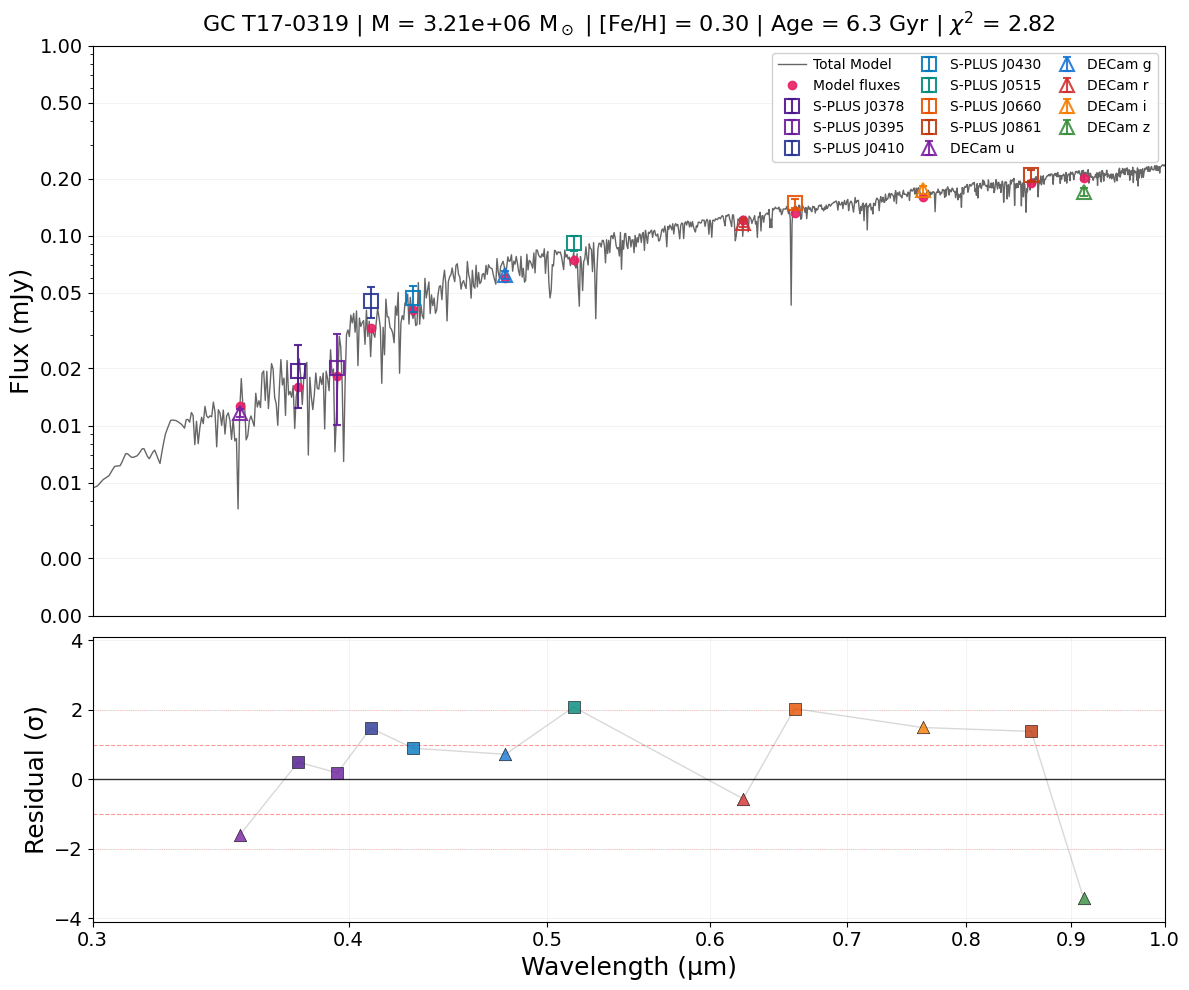


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-0319
Filtro          λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
----------------------------------------------------------------------
DECam u         0.354    0.011696     0.012647     -1.60        1.60      
S-PLUS J0378    0.378    0.019446     0.015912     0.50         0.50      
S-PLUS J0395    0.395    0.020214     0.018346     0.18         0.18      
S-PLUS J0410    0.410    0.045086     0.032825     1.48         1.48      
S-PLUS J0430    0.430    0.047090     0.040583     0.90         0.90      
DECam g         0.477    0.061948     0.059678     0.72         0.72      
S-PLUS J0515    0.515    0.091362     0.074122     2.08         2.08      
DECam r         0.623    0.116957     0.120298     -0.56        0.56      
S-PLUS J0660    0.660    0.148162     0.131392     2.04         2.04      
DECam i         0.762    0.173791     0.160601     1.49         1.49      
S-PLUS J0861    0.861    0.207957     0.189101     1.38

In [14]:
plot_splus_gc_sed_with_residuals('T17-0319')

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.000400
📊 Analizando objeto T17-0382:
   Masa estelar: 1.00e+06 M_sun
   Metalicidad Z REAL: 0.000400
   [Fe/H]: -1.580
   Edad: 11998 Myr
   χ² reducido: 1.23
🔍 Comparación:
   - Metalicidad real del modelo: 0.000400
✅ Gráfico guardado: ../anac_data/CIGALE-Final//T17-0382_SED_S-PLUS_DECam.png


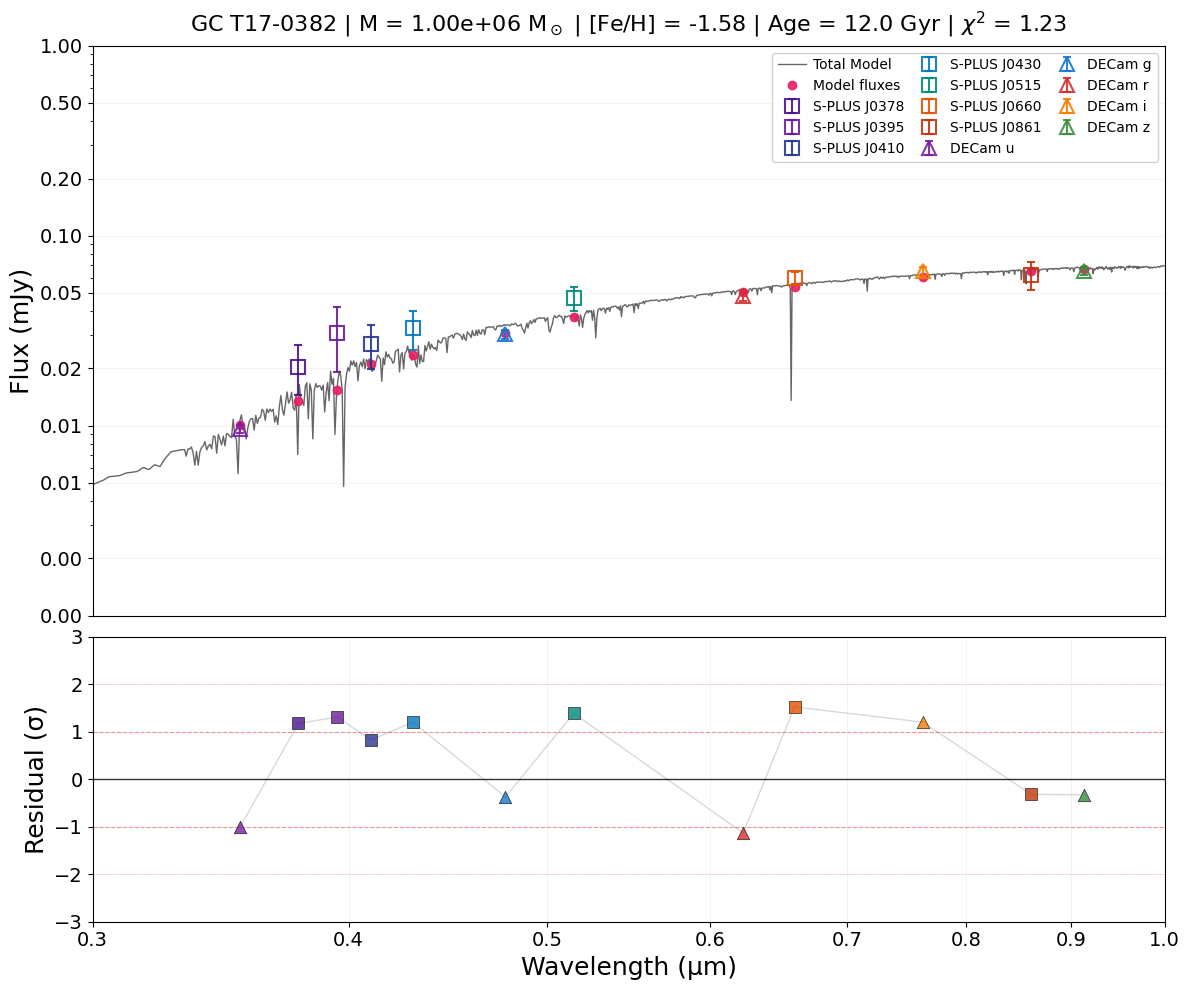


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-0382
Filtro          λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
----------------------------------------------------------------------
DECam u         0.354    0.009639     0.010134     -1.01        1.01      
S-PLUS J0378    0.378    0.020440     0.013413     1.18         1.18      
S-PLUS J0395    0.395    0.030705     0.015465     1.31         1.31      
S-PLUS J0410    0.410    0.026959     0.021165     0.83         0.83      
S-PLUS J0430    0.430    0.032539     0.023594     1.20         1.20      
DECam g         0.477    0.030201     0.030773     -0.37        0.37      
S-PLUS J0515    0.515    0.046922     0.037154     1.39         1.39      
DECam r         0.623    0.047866     0.050619     -1.13        1.13      
S-PLUS J0660    0.660    0.059948     0.053511     1.52         1.52      
DECam i         0.762    0.064867     0.060891     1.21         1.21      
S-PLUS J0861    0.861    0.062203     0.065539     -0.3

In [15]:
plot_splus_gc_sed_with_residuals('T17-0382')

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.030000
📊 Analizando objeto T17-2075:
   Masa estelar: 1.11e+06 M_sun
   Metalicidad Z REAL: 0.030000
   [Fe/H]: 0.295
   Edad: 10989 Myr
   χ² reducido: 2.15
🔍 Comparación:
   - Metalicidad real del modelo: 0.030000
✅ Gráfico guardado: ../anac_data/CIGALE-Final//T17-2075_SED_S-PLUS_DECam.png


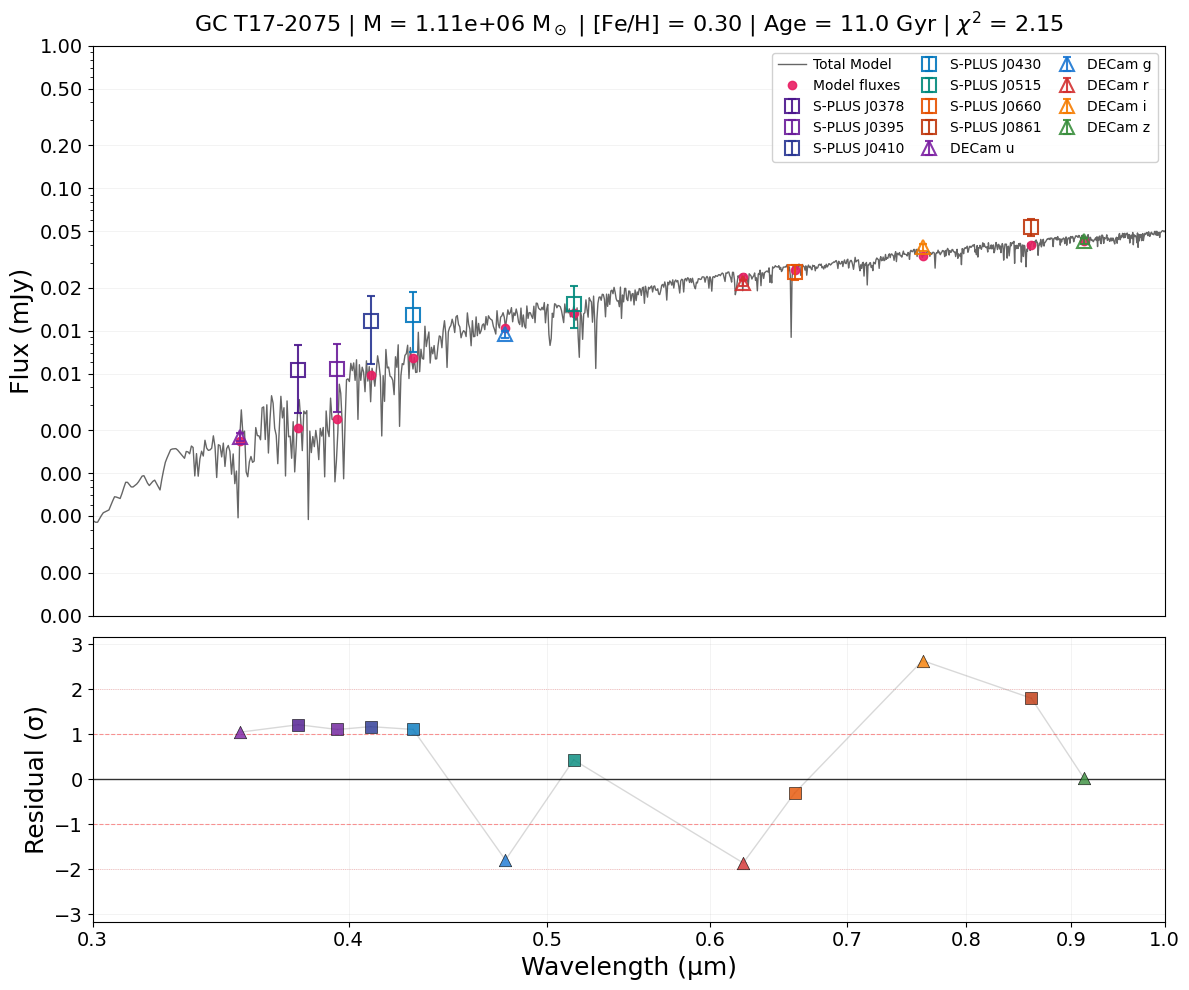


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-2075
Filtro          λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
----------------------------------------------------------------------
DECam u         0.354    0.001803     0.001675     1.05         1.05      
S-PLUS J0378    0.378    0.005288     0.002061     1.21         1.21      
S-PLUS J0395    0.395    0.005369     0.002379     1.11         1.11      
S-PLUS J0410    0.410    0.011642     0.004882     1.17         1.17      
S-PLUS J0430    0.430    0.012866     0.006385     1.11         1.11      
DECam g         0.477    0.009463     0.010434     -1.80        1.80      
S-PLUS J0515    0.515    0.015448     0.013254     0.43         0.43      
DECam r         0.623    0.021678     0.023828     -1.86        1.86      
S-PLUS J0660    0.660    0.025618     0.026560     -0.31        0.31      
DECam i         0.762    0.038373     0.033220     2.64         2.64      
S-PLUS J0861    0.861    0.053285     0.039918     1.80

In [16]:
plot_splus_gc_sed_with_residuals('T17-2075')

🔍 Metalicidad encontrada en 'best.stellar.metallicity': 0.030000
📊 Analizando objeto T17-0387:
   Masa estelar: 1.47e+06 M_sun
   Metalicidad Z REAL: 0.030000
   [Fe/H]: 0.295
   Edad: 8987 Myr
   χ² reducido: 1.39
🔍 Comparación:
   - Metalicidad real del modelo: 0.030000
✅ Gráfico guardado: ../anac_data/CIGALE-Final//T17-0387_SED_S-PLUS_DECam.png


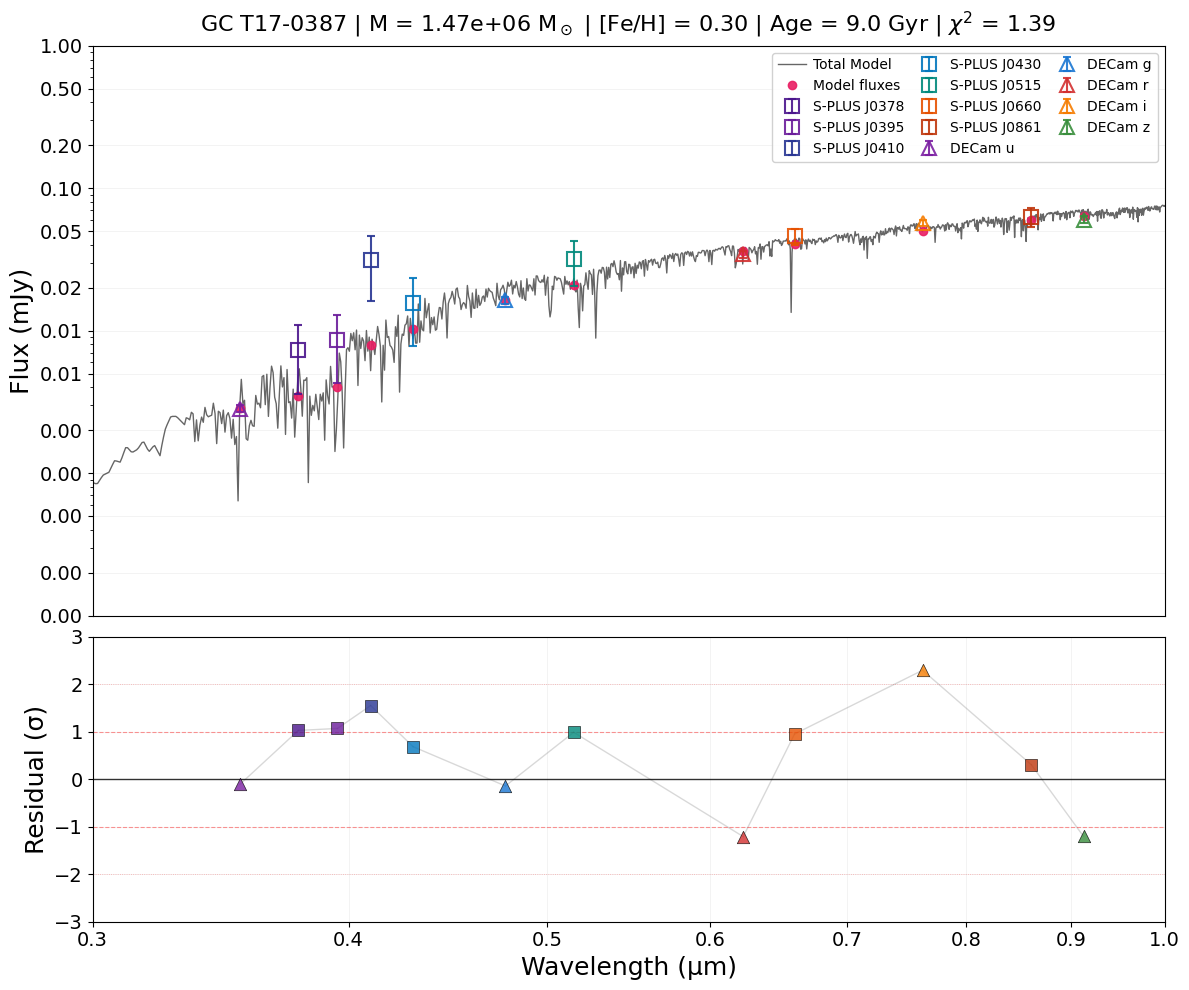


ANÁLISIS DE RESIDUOS - Cúmulo Globular T17-0387
Filtro          λ (μm)   Obs (mJy)    Model (mJy)  Residuo (σ)  |Residuo| 
----------------------------------------------------------------------
DECam u         0.354    0.002832     0.002849     -0.11        0.11      
S-PLUS J0378    0.378    0.007257     0.003504     1.03         1.03      
S-PLUS J0395    0.395    0.008637     0.003990     1.07         1.07      
S-PLUS J0410    0.410    0.031264     0.007976     1.55         1.55      
S-PLUS J0430    0.430    0.015700     0.010279     0.69         0.69      
DECam g         0.477    0.016294     0.016416     -0.14        0.14      
S-PLUS J0515    0.515    0.031664     0.020786     0.99         0.99      
DECam r         0.623    0.034358     0.036466     -1.21        1.21      
S-PLUS J0660    0.660    0.045960     0.040459     0.95         0.95      
DECam i         0.762    0.057020     0.050362     2.30         2.30      
S-PLUS J0861    0.861    0.063243     0.060254     0.31

In [17]:
plot_splus_gc_sed_with_residuals('T17-0387')